# K-Nearest Neighbor Lab
Read over the sklearn info on [nearest neighbor learners](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification)




In this lab you will use scikit-learn's k-nearest-neighbor implementations to classify the Glass and Magic Telescope datasets and to regress house prices, exploring the effects of normalization, distance weighting, and *k*. You will also design your own distance metric for mixed nominal-and-real data. Section percentages sum to 100%, with an optional 15% extra credit for coding KNN yourself.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1 K-Nearest Neighbor (KNN) algorithm

### 1.1 (15%) Basic KNN Classification

Learn the [Glass data set](https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/glass_train.arff) using [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) with default parameters.
- Randomly split your data into train/test.  Anytime we don't tell you specifics (such as what percentage is train vs test) choose your own reasonable values
- Give typical train and test set accuracies after running with different random splits
- Print the output probabilities for a test set (predict_proba)
- Try it with different p values (Minkowskian exponent) and discuss any differences

Different Size Train/Test split averages
Training set
[np.float64(0.6982456140350877), np.float64(0.6887850467289719), np.float64(0.6762376237623762), np.float64(0.671578947368421), np.float64(0.6590909090909091), np.float64(0.6621951219512195), np.float64(0.6618421052631579), np.float64(0.6608695652173913), np.float64(0.6460317460317461)]
Testing set
[np.float64(0.5230769230769232), np.float64(0.535), np.float64(0.5846153846153845), np.float64(0.584375), np.float64(0.5769230769230769), np.float64(0.5644444444444444), np.float64(0.5725490196078431), np.float64(0.5741379310344827), np.float64(0.571875)]
Train - Test
Overall Avg Accuracy:	0.6694307421610313	0.5652218644113506
Median accuracy:	0.6621951219512195	0.5725490196078431


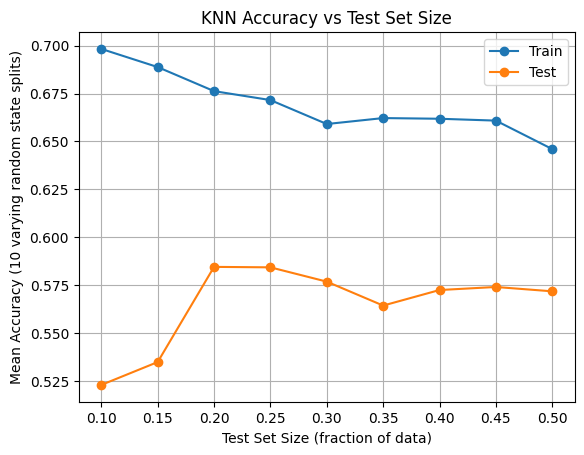

Training/test size chart done. Moving to minkowskian split.
Minkowskian Test Results:
Array of Accuracy:
Training acc:
 [0.6831683168316832, 0.6633663366336634, 0.6633663366336634, 0.6435643564356436, 0.6336633663366337, 0.6336633663366337, 0.6534653465346535, 0.6534653465346535, 0.6534653465346535, 0.6534653465346535] 
Testing acc:
 [0.6923076923076923, 0.5769230769230769, 0.5769230769230769, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154]
Train-Test
Accuracy Avg:	0.6534653465346535	0.6153846153846154
Median Acc:	0.6534653465346535	[0.6923076923076923, 0.5769230769230769, 0.5769230769230769, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154]


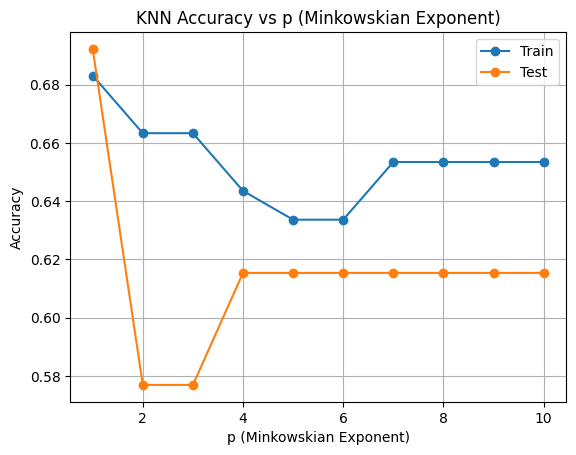

     build wind float  build wind non-float  containers  headlamps  tableware  \
26                0.2                   0.8         0.0        0.0        0.0   
111               0.0                   0.0         0.0        1.0        0.0   
81                0.4                   0.6         0.0        0.0        0.0   
55                0.6                   0.2         0.0        0.0        0.0   
44                0.4                   0.0         0.0        0.2        0.0   
96                0.0                   0.0         0.0        1.0        0.0   
80                1.0                   0.0         0.0        0.0        0.0   
125               0.6                   0.4         0.0        0.0        0.0   
114               0.8                   0.2         0.0        0.0        0.0   
62                0.6                   0.2         0.0        0.0        0.0   
45                1.0                   0.0         0.0        0.0        0.0   
4                 0.0       

In [3]:
import io
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def training_size_check(
    X, y, min_size, max_size, interval=0.05, neighbors=5, rand_state_range=10
):
    # input data for a test set where the variable is the split
    # return the x axis and two data sets, test_sizes_arr train_acc and test_acc,

    # find how many intervals are between min and max
    n_steps = round((max_size - min_size) / interval) + 1

    # this calculates the x-axis that we're going to use to plot the graph
    test_sizes = np.round(np.linspace(min_size, max_size, n_steps), 4)

    train_acc_arr, test_acc_arr = [], []

    # for each test size in between the
    for test_size in test_sizes:
        train_scores, test_scores = [], []

        # check the test size over r different seeds
        for seed in range(rand_state_range):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )

            # setup the knn
            knn = KNeighborsClassifier(n_neighbors=neighbors)
            knn.fit(X_train, y_train)

            # save the accuracies
            train_acc = knn.score(X_train, y_train)
            test_acc = knn.score(X_test, y_test)

            train_scores.append(train_acc)
            test_scores.append(test_acc)

        train_acc_arr.append(np.mean(train_scores))
        test_acc_arr.append(np.mean(test_scores))

    return test_sizes, train_acc_arr, test_acc_arr


def minkowskian_check(X, y, p_min, p_max, neighbors=5, test_size=0.2, rand_state=42):
    # test for changes in p on the same data set.
    p_range = p_max - p_min
    p_val_array = []
    train_acc_arr, test_acc_arr = [], []

    # since we want to test only the changes in p, we have a estatic data set defined here
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=rand_state
    )

    for i in range(p_range+1):
        # set up the classifier
        p_val = p_min + i
        p_val_array.append(p_val)
        knn = KNeighborsClassifier(n_neighbors=neighbors, p=p_val)
        knn.fit(X_train, y_train)

        # save the accuracies
        train_acc = knn.score(X_train, y_train)
        test_acc = knn.score(X_test, y_test)

        train_acc_arr.append(train_acc)
        test_acc_arr.append(test_acc)

    return p_val_array, train_acc_arr, test_acc_arr


def print_probs(n_rows, X, y, k=5, t=0.2, rand_state=42, p=2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=t, random_state=rand_state
    )
    knn = KNeighborsClassifier(n_neighbors=k, p=p).fit(X_train, y_train)
    probs = knn.predict_proba(X_test)
    df = pd.DataFrame(probs, columns=knn.classes_, index=X_test.index).round(2)
    df["Predicted"] = knn.predict(X_test)
    df["Actual"] = y_test
    df["Correct"] = df["Predicted"] == df["Actual"]
    print(df.head(n_rows))


## READABILITY FUNCTIONS ##
def avg_array(arr):
    # take in an array and get the average
    return sum(arr) / len(arr)


# def mode_array(arr):
#     # take in an array and return the mode
#     return stats.mode(arr, keepdims=False)


def median_array(arr):
    # take in an array and return the median
    return np.median(arr)


def main():
    # Get the data
    url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/glass_train.arff"
    with urllib.request.urlopen(url) as response:
        raw_data = response.read().decode("utf-8")

    # Put data into a dataframe
    data, _ = arff.loadarff(io.StringIO(raw_data))
    df = pd.DataFrame(data)

    # Define X and Y
    # X = the type column
    X = df.drop(columns=["Type"])
    # y = everything bar X
    y = df["Type"].str.decode("utf-8")

    # test/training splits test
    t_sizes, t_size_train_acc, t_size_test_acc = training_size_check(
        X, y, 0.1, 0.5, 0.05
    )
    print("Different Size Train/Test split averages")
    print(f"Training set\n{t_size_train_acc}\nTesting set\n{t_size_test_acc}")
    print(
        f"Train - Test\nOverall Avg Accuracy:\t{avg_array(t_size_train_acc)}\t{avg_array(t_size_test_acc)}"
    )
    # print(f"Mode accuracy:\t{mode_array(t_size_train_acc)}\t{mode_array(t_size_test_acc)}")
    print(
        f"Median accuracy:\t{median_array(t_size_train_acc)}\t{median_array(t_size_test_acc)}"
    )

    pd.DataFrame(
        {"Train": t_size_train_acc, "Test": t_size_test_acc},
        index=t_sizes,
    ).plot(
        marker="o",
        xlabel="Test Set Size (fraction of data)",
        ylabel="Mean Accuracy (10 varying random state splits)",
        title="KNN Accuracy vs Test Set Size",
        grid=True,
    )
    plt.show()
    print("Training/test size chart done. Moving to minkowskian split.")

    p_axis, p_train_acc, p_test_acc = minkowskian_check(X, y, 1, 10)
    print("Minkowskian Test Results:\nArray of Accuracy:")
    print("Training acc:\n", p_train_acc, "\nTesting acc:\n", p_test_acc)
    print(
        f"Train-Test\nAccuracy Avg:\t{avg_array(p_train_acc)}\t{avg_array(p_test_acc)}"
    )
    # print(f"Mode Acc:\t{mode_array(p_train_acc)}\t{mode_array(p_test_acc)}")
    print(f"Median Acc:\t{median_array(p_train_acc)}\t{p_test_acc}")

    pd.DataFrame(
        {"Train": p_train_acc, "Test": p_test_acc},
        index=p_axis,
    ).plot(
        marker="o",
        xlabel="p (Minkowskian Exponent)",
        ylabel="Accuracy",
        title="KNN Accuracy vs p (Minkowskian Exponent)",
        grid=True,
    )
    plt.show()

    print_probs(50, X, y)
    print("Done!")

if __name__ == "__main__":
    main()


## 2 KNN Classification with normalization and distance weighting

Use the [magic telescope](https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff) dataset

### 2.1 (5%) - Without Normalization or Distance Weighting
- Do random 80/20 train/test splits each time
- Run with k=3 and *without* distance weighting and *without* normalization
- Show train and test set accuracy

k=3, uniform weights, no normalization


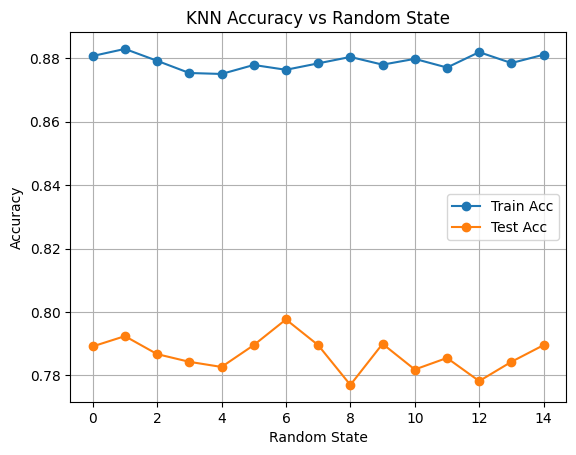

Test set accuracy scores:		 [0.7891541885876163, 0.792391744233104, 0.7867260218535006, 0.7842978551193849, 0.782679077296641, 0.7895588830433024, 0.7976527721570215, 0.7895588830433024, 0.7770133549170376, 0.7899635774989883, 0.7818696883852692, 0.7855119384864427, 0.7782274382840955, 0.7842978551193849, 0.7895588830433024]
Train set accuracy scores:		 [0.8807042396033593, 0.8829302843266215, 0.8791864818374987, 0.8753414954973187, 0.8750379439441465, 0.8778710917737529, 0.8763533340078924, 0.8783770110290398, 0.8804006880501872, 0.8779722756248103, 0.879793584943843, 0.8770616209652939, 0.8819184458160477, 0.8784781948800972, 0.8811089750075888]
Average Training Accuracy:		 0.8788357111538332
Average Testing Accuracy:		 0.7865641440712262


In [6]:
# Imports
import io
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def iterations(X, y, i):
    test_acc_arr, train_acc_arr = [], []

    for h in range(i):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=h
        )
        # this enforces the 80-20 split, with different random states
        # random states are used so that results are replicable, but also different

        knn = KNeighborsClassifier(n_neighbors=3, weights="uniform")
        # uniform weights does the whole "no distance weighting"

        knn.fit(X_train, y_train)  # and no data cleanup

        # capture the test and train scores
        test_acc = knn.score(X_test, y_test)
        train_acc = knn.score(X_train, y_train)
        test_acc_arr.append(test_acc)
        train_acc_arr.append(train_acc)

    # loop end
    pd.DataFrame(
        {"Train Acc": train_acc_arr, "Test Acc": test_acc_arr}, index=range(i)
    ).plot(
        marker="o",
        xlabel="Random State",
        ylabel="Accuracy",
        title="KNN Accuracy vs Random State",
        grid=True,
    )
    plt.show()

    # print scores
    print("Test set accuracy scores:\t\t", test_acc_arr)
    print("Train set accuracy scores:\t\t", train_acc_arr)
    train_avg = sum(train_acc_arr) / len(train_acc_arr)
    test_avg = sum(test_acc_arr) / len(test_acc_arr)

    print("Average Training Accuracy:\t\t", train_avg)
    print("Average Testing Accuracy:\t\t", test_avg)


def main():
    #
    # Get the data
    url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff"
    with urllib.request.urlopen(url) as response:
        raw_data = response.read().decode("utf-8")

    # Put data into a dataframe
    data, _ = arff.loadarff(io.StringIO(raw_data))
    df = pd.DataFrame(data)

    # define X, y
    # X = the type column
    X = df.drop(columns=["class"])
    # y = everything bar X
    y = df["class"].str.decode("utf-8")

    # loop to capture results
    print("k=3, uniform weights, no normalization")
    iterations(X, y, 15)


if __name__ == "__main__":
    main()


#### Discussion
What did you observe in your results?

1. Accuracy bounces around a lot, remaining around 75-80% testing and 85 - 90% training set accuracy.
2. Training accuracy remains more consistent across the different splits than testing accuracy.


### 2.2 (10%) With Normalization
- Try it with k=3 without distance weighting but *with* normalization of input features.  You may use any reasonable normalization approach (e.g. standard min-max normalization between 0-1, z-transform, etc.)

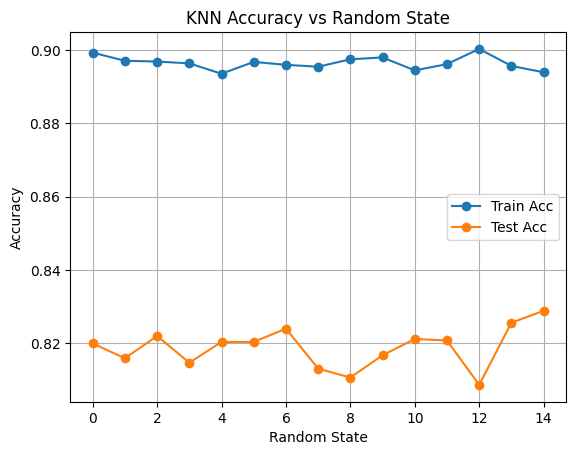

Test set accuracy scores:		 [0.8199109672197491, 0.8158640226628895, 0.8219344394981789, 0.8146499392958316, 0.820315661675435, 0.820315661675435, 0.8239579117766087, 0.8130311614730878, 0.8106029947389721, 0.8166734115742614, 0.821125050586807, 0.820720356131121, 0.8085795224605423, 0.8255766895993525, 0.8288142452448402]
Train set accuracy scores:		 [0.8993220681979156, 0.8970960234746534, 0.8968936557725387, 0.8963877365172519, 0.8935545886876455, 0.8967924719214814, 0.8959830011130223, 0.8954770818577356, 0.8975007588788829, 0.8980066781341698, 0.8944652433471618, 0.8961853688151371, 0.9003339067084893, 0.8956794495598502, 0.893959324091875]
Average Training Accuracy:		 0.8965091571385208
Average Testing Accuracy:		 0.8188048023742075


In [7]:
# Imports
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import urllib.request
import io
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler

def iterations(X_norm, y, i):
    test_acc_arr, train_acc_arr = [], []

    for h in range(i):
        X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=h)
        # this enforces the 80-20 split, with different random states
        # random states are used so that results are replicable, but also different

        knn = KNeighborsClassifier(n_neighbors=3, weights="uniform")
        # uniform weights does the whole "no distance weighting"

        knn.fit(X_train, y_train) # and no data cleanup
        y_pred = knn.predict(X_test)

        # capture the test and train scores
        test_acc = knn.score(X_test, y_test)
        train_acc = knn.score(X_train, y_train)
        test_acc_arr.append(test_acc)
        train_acc_arr.append(train_acc)

  # loop end
    pd.DataFrame(
        {"Train Acc": train_acc_arr, "Test Acc": test_acc_arr}, index=range(i)
    ).plot(
        marker="o",
        xlabel="Random State",
        ylabel="Accuracy",
        title="KNN Accuracy vs Random State",
        grid=True,
    )
    plt.show()

    print("Test set accuracy scores:\t\t", test_acc_arr)
    print("Train set accuracy scores:\t\t", train_acc_arr)

    train_avg = sum(train_acc_arr)/len(train_acc_arr)
    test_avg = sum(test_acc_arr)/len(test_acc_arr)

    print("Average Training Accuracy:\t\t", train_avg)
    print("Average Testing Accuracy:\t\t", test_avg)


def main():
    #
    # Get the data
    url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff"
    with urllib.request.urlopen(url) as response:
        raw_data = response.read().decode("utf-8")

    # Put data into a dataframe
    data, metadata = arff.loadarff(io.StringIO(raw_data))
    df = pd.DataFrame(data)

    # define X, y
    # X = the type column
    X = df.drop(columns=["class"])
    # y = everything bar X
    y = df["class"].str.decode("utf-8")

    # normalize
    # Whatever normalizaion I choose to implement goes here
    scaler = MinMaxScaler().set_output(transform="pandas")
    X_norm = scaler.fit_transform(X)

    # loop to capture results

    iterations(X_norm, y, 15)

if __name__ == "__main__":
    main()





#### Discussion
Discuss the results of using normalized data vs. unnormalized data

While normalization did not have a massive effect on the results, it increased the  testing set accuracy by ~1-3% compared to the not-normalized data set and raised the average by ~2%.

Ultimately, this seems like an easy enough change to get a decent uptick in accuracy, though it isn't a massive jump


### 2.3 (10%) With Distance Weighting
- Try it with k=3 and with distance weighting *and* normalization

#### Discussion
Comparison and discuss the differences you see with distance weighting and normalization vs without.

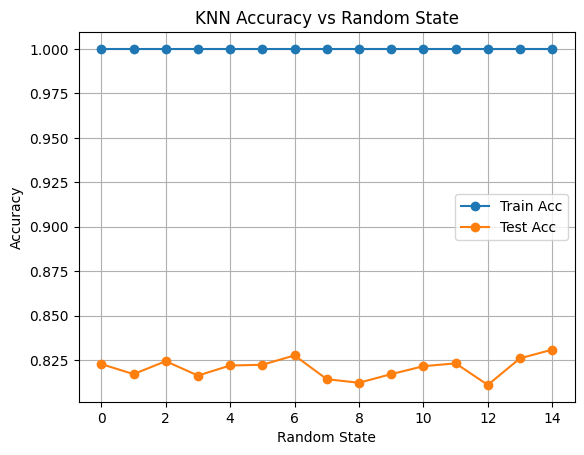

Test set accuracy scores:		 [0.8227438284095507, 0.8170781060299473, 0.8243626062322946, 0.8162687171185755, 0.8219344394981789, 0.8223391339538648, 0.8276001618777823, 0.8142452448401457, 0.8122217725617159, 0.8170781060299473, 0.8215297450424929, 0.8231485228652368, 0.811007689194658, 0.8259813840550384, 0.83083771752327]
Train set accuracy scores:		 [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Average Training Accuracy:		 1.0
Average Testing Accuracy:		 0.8205584783488467


In [9]:
# Imports
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import urllib.request
import io
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler

def iterations(X_norm, y, i):
  test_acc_arr, train_acc_arr = [], []

  for h in range(i):
    X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=h)
    # this enforces the 80-20 split, with different random states
    # random states are used so that results are replicable, but also different

    knn = KNeighborsClassifier(n_neighbors=3, weights="distance")
    # uniform weights does the whole "no distance weighting"

    knn.fit(X_train, y_train) # and no data cleanup
    y_pred = knn.predict(X_test)

    # capture the test and train scores
    test_acc = knn.score(X_test, y_test)
    train_acc = knn.score(X_train, y_train)
    test_acc_arr.append(test_acc)
    train_acc_arr.append(train_acc)
  # loop end

  pd.DataFrame(
      {"Train Acc": train_acc_arr, "Test Acc": test_acc_arr}, index=range(i)
  ).plot(
      marker="o",
      xlabel="Random State",
      ylabel="Accuracy",
      title="KNN Accuracy vs Random State",
      grid=True,
  )
  plt.show()
  print("Test set accuracy scores:\t\t", test_acc_arr)
  print("Train set accuracy scores:\t\t", train_acc_arr)

  train_avg = sum(train_acc_arr)/len(train_acc_arr)
  test_avg = sum(test_acc_arr)/len(test_acc_arr)

  print("Average Training Accuracy:\t\t", train_avg)
  print("Average Testing Accuracy:\t\t", test_avg)


def main():
  #
  # Get the data
  url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff"
  with urllib.request.urlopen(url) as response:
    raw_data = response.read().decode("utf-8")

  # Put data into a dataframe
  data, metadata = arff.loadarff(io.StringIO(raw_data))
  df = pd.DataFrame(data)

  # define X, y
  # X = the type column
  X = df.drop(columns=["class"])
  # y = everything bar X
  y = df["class"].str.decode("utf-8")

  # normalize
  # Whatever normalizaion I choose to implement goes here
  scalar = MinMaxScaler().set_output(transform="pandas")
  X_norm = scalar.fit_transform(X)

  # loop to capture results

  iterations(X_norm, y, 15)

if __name__ == "__main__":
  main()

**Discussion**

It took less than a single line of code to add the distance weighting.

Compared to the previous two iterations of the knn algorithm, this reduced the average testing accuracy to 81.9% from the 82% of the normalization, but the average training set accuracy became 100% (From 89%).

It also appears, in the graph, that the variance in the accuracy has decreased.


**bold text**### 2.4 (10%) Different k Values
- Using your normalized data with distance weighting, create one graph with classification accuracy on the test set on the y-axis and k values on the x-axis.
- Use values of k from 1 to 15.  Use the same train/test split for each.

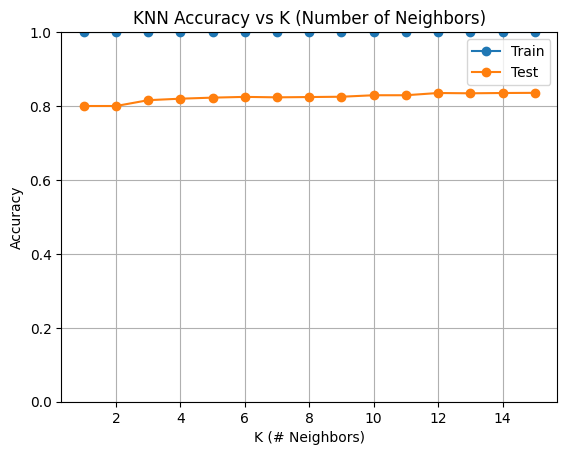

In [ ]:
# Imports
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import urllib.request
import io



# Get the data
url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff"
with urllib.request.urlopen(url) as response:
  raw_data = response.read().decode("utf-8")

# Put data into a dataframe
data, metadata = arff.loadarff(io.StringIO(raw_data))
df = pd.DataFrame(data)

# define X, y
# X = the type column
X = df.drop(columns=["class"])
# y = everything bar X
y = df["class"].str.decode("utf-8")

# normalize
# Whatever normalizaion I choose to implement goes here
scaler = MinMaxScaler().set_output(transform="pandas")
X_norm = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)
test_acc_arr, train_acc_arr = [], []

num_itr = 15
for i in range(num_itr):
  # fit the model with sizes from 1-X
  knn = KNeighborsClassifier(n_neighbors=i+1, weights="distance")
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  # capture the testing scores
  test_acc = knn.score(X_test, y_test)
  train_acc = knn.score(X_train, y_train)
  test_acc_arr.append(test_acc)
  train_acc_arr.append(train_acc)

# plot a chart with the results where x = k and y = 0-1
pd.DataFrame(
    {'Train':train_acc_arr, 'Test':test_acc_arr},
    index=range(1,num_itr+1)).plot(marker='o', xlabel='K (# Neighbors)', ylabel='Accuracy',
      ylim=(0, 1), title='KNN Accuracy vs K (Number of Neighbors)', grid=True)
plt.show()




#### Discussion
How do the k values affect your results?

- The higher k values increase the testing set accuracy slightly. It looks like ~1-2%.

## 3 KNN Regression with normalization and distance weighting

Use the [sklean KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) on the [housing price prediction](https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/housing_train.arff) problem.  
### 3.1 (5%) Ethical Data
This is the classic Boston Housing dataset. It contains a feature that encodes a racial proxy of each neighborhood, and using it as a predictor bakes that bias into any model trained on it. scikit-learn deprecated `load_boston` in version 1.2 for exactly this reason (see the [sklearn note](https://scikit-learn.org/1.0/modules/generated/sklearn.datasets.load_boston.html)). Look at the feature list, identify the inappropriate feature, and discuss in one paragraph *which* feature it is, *why* it is a problem, and *what* you would do about it if you were shipping this model.


#### Discussion
Discuss the inappropriate feature. Which one and why?

Okay, so this one was a bit dumb: at first I thought it was the AGE variable, but I was completely blind. It's of course, #12 B which is so obviously racist I'm surprised I missed it in my first look at the dataset. I guess my eyes just glazed over it.

```
%     12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks
%                  by town
```

So, why is it innapropriate? Because it is literally inserting the human bias (i.e. Racism) against black people into the dataset, which will then be passed on to any machine learning algorithm. This will then cause the resulting system to implement the same racist bias as the dataset's creators.


### 3.2 (15%) - KNN Regression
- Do random 80/20 train/test splits each time
- Run with k=3
- Print the score (coefficient of determination) and Mean Absolute Error (MAE) for the train and test set for the cases of
  - No input normalization and no distance weighting
  - Normalization and no distance weighting
  - Normalization and distance weighting
- Normalize inputs features where needed but do not normalize the output

In [ ]:
# housing dataset project goes here


import io
import urllib.request

import pandas as pd
from scipy.io import arff
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler


def knr_iteration(df: pd.DataFrame, r_state: int,
              input_norm: bool = False, dist_weight: bool = False,
              y_class: str = 'MEDV', k_neighbors: int = 3):

    X = df.drop(columns=[y_class])
    y = df[y_class]

    # transform the X based on input_norm
    if input_norm: # is true
        normalizer = MinMaxScaler()
        X = normalizer.fit_transform(X)

    # create and fit model as knr
    # params based on dist_weight
    if dist_weight:
        knr = KNeighborsRegressor(n_neighbors=k_neighbors, weights='distance')
    else:
        knr = KNeighborsRegressor(n_neighbors=k_neighbors, weights='uniform')

    # create the test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r_state)

    # fit the model
    knr.fit(X_train, y_train)

    # capture the model's scores
    mae_results = []
    score_results = []

    mae_results.append(mean_absolute_error(y_train, knr.predict(X_train)))
    mae_results.append(mean_absolute_error(y_test, knr.predict(X_test)))

    score_results.append(knr.score(X_train, y_train))
    score_results.append(knr.score(X_test, y_test))

    # return score and MAE
    return mae_results, score_results

def main():
    url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/housing_train.arff"

    # get the data from the provided link
    with urllib.request.urlopen(url) as response:
        raw_data = response.read().decode("utf-8")

    # Put data into a dataframe
    data, meta = arff.loadarff(io.StringIO(raw_data))
    df = pd.DataFrame(data)
    df.columns = meta.names()

    # df = df.drop(columns=[b'B']) # remove the offending data
    df['CHAS'] = df['CHAS'].astype(int) # in case it decides to use bytestrings

    # nothing turned on iteration
    mae_arr1, score_arr1 = knr_iteration(df, 1)
    print(f"""\'Nothing On\' Set Results\nTraining Set Results\n\tMAE: {mae_arr1[0]}\n\tScore: {score_arr1[0]}\n\nTesting Set Results\n\tMAE: {mae_arr1[1]}\n\tScore: {score_arr1[1]}\n\n""")

    mae_arr2, score_arr2 = knr_iteration(df, 1, True)
    print(f"""\'Normalization On\' Set Results\nTraining Set Results\n\tMAE: {mae_arr2[0]}\n\tScore: {score_arr2[0]}\n\nTesting Set Results\n\tMAE: {mae_arr2[1]}\n\tScore: {score_arr2[1]}\n\n""")

    mae_arr3, score_arr3 = knr_iteration(df, 1, True, True)
    print(f"""\'Everything On\' Set Results\nTraining Set Results\n\tMAE: {mae_arr3[0]}\n\tScore: {score_arr3[0]}\n\nTesting Set Results\n\tMAE: {mae_arr3[1]}\n\tScore: {score_arr3[1]}\n\n""")

if __name__ == "__main__":
  main()

'Nothing On' Set Results
Training Set Results
	MAE: 3.0254578754578754
	Score: 0.796795306367391

Testing Set Results
	MAE: 3.751648351648351
	Score: 0.43934509804091104


'Normalization On' Set Results
Training Set Results
	MAE: 2.072252747252747
	Score: 0.8867259385190857

Testing Set Results
	MAE: 2.4967032967032967
	Score: 0.7200447441025523


'Everything On' Set Results
Training Set Results
	MAE: 0.0
	Score: 1.0

Testing Set Results
	MAE: 2.2317101316269192
	Score: 0.8136391432996262




#### Discussion
Discuss your results. How did the hyperparameters affect your results? Discuss each one and combinations of each.

As the hyperparameters are added, the regression algorithm became better: the mean average of error decreased on both the training and test sets, and the accuracy on the sets rose.  

### 3.3 (10%)  Different k Values
- Using housing with normalized data and distance weighting, create one graph with MAE on the test set on the y-axis and k values on the x-axis
- Use values of k from 1 to 15.  Use the same train/test split for each.

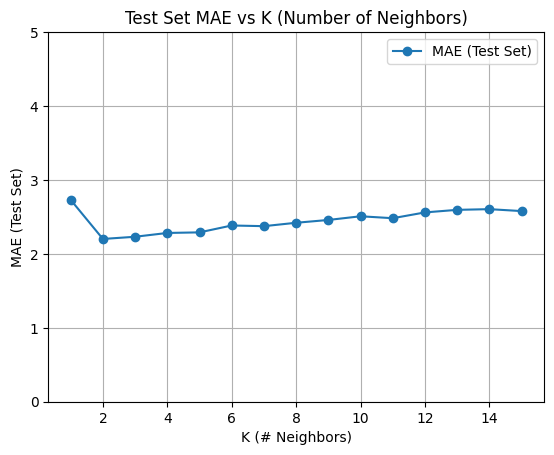

In [ ]:
import io
import urllib.request

import pandas as pd
from scipy.io import arff
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


def knr_iteration(df: pd.DataFrame, r_state: int,
              input_norm: bool = False, dist_weight: bool = False,
              k_neighbors: int = 3,
              y_class: str = 'MEDV'):

    X = df.drop(columns=[y_class])
    y = df[y_class]

    # transform the X based on input_norm
    if input_norm: # is true
        normalizer = MinMaxScaler()
        X = normalizer.fit_transform(X)

    # create and fit model as knr
    # params based on dist_weight
    if dist_weight:
        knr = KNeighborsRegressor(n_neighbors=k_neighbors, weights='distance')
    else:
        knr = KNeighborsRegressor(n_neighbors=k_neighbors, weights='uniform')

    # create the test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r_state)

    # fit the model
    knr.fit(X_train, y_train)

    # capture the model's scores
    mae_results = []
    score_results = []

    mae_results.append(mean_absolute_error(y_train, knr.predict(X_train)))
    mae_results.append(mean_absolute_error(y_test, knr.predict(X_test)))

    score_results.append(knr.score(X_train, y_train))
    score_results.append(knr.score(X_test, y_test))

    # return score and MAE
    return mae_results#, score_results

def main():
    url = "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/housing_train.arff"

    # get the data from the provided link
    with urllib.request.urlopen(url) as response:
        raw_data = response.read().decode("utf-8")

    # Put data into a dataframe
    data, meta = arff.loadarff(io.StringIO(raw_data))
    df = pd.DataFrame(data)
    df.columns = meta.names()

    # df = df.drop(columns=[b'B']) # remove the offending data
    df['CHAS'] = df['CHAS'].astype(int) # in case it decides to use bytestrings
    num_itr = 15
    test_mae_to_k = []
    for i in range(num_itr):
        k = i+1
        mae_arr = knr_iteration(df, 1, True, True, k)
        test_mae_to_k.append(mae_arr[1])

    pd.DataFrame(
        {'MAE (Test Set)':test_mae_to_k},
        index=range(1, num_itr+1)
    ).plot(
        marker='o', xlabel='K (# Neighbors)', ylabel='MAE (Test Set)',
        ylim=(0, 5), title='Test Set MAE vs K (Number of Neighbors)', grid=True)
    plt.show()




if __name__ == "__main__":
  main()

#### Discussion
How did the k values affect your results for this dataset? How does that compare to your previous work in this lab?

- The MAE dramatically decreased when going from k=1 to 2, then gradually rose until ~k=35 when it equaled the MAE of k=1.
- After ~k=35, the MAE continued to increase with higher k values.
- The number of instances can be changed by editing the `num_itr` value, which I've messed around with but returned to 15. Don't increase it beyond 364, though, since that is the size of the test set.
- This differs from the KNeighbors classifier in that the number of neighbors causes the MAE to rise, which is somewhat equivalent to falling accuracy--which is different from the rising then stabilizing accuracy of the KNeighborsClassifier when neighbors increased. TLDR: Too many neighbors throws the regressor off more than the classifier.


## 4. (20%) KNN with nominal and real data

- Use the [Lymphography dataset](https://archive.ics.uci.edu/dataset/63/lymphography) from UCI. You can install `ucimlrepo` (`!pip install ucimlrepo`) and load it with `from ucimlrepo import fetch_ucirepo; ds = fetch_ucirepo(id=63)`, or download the ARFF from UCI directly.
- Use a 80/20 split of the data for the training/test set
- This dataset has both continuous and nominal attributes
- Implement a distance metric which uses Euclidean distance for continuous features and 0/1 distance for nominal. Hints:
    - Change the nominal features in the data set to integer values since KNeighborsClassifier expects numeric features. I used `LabelEncoder` on the nominal features.
    - Keep a list of which features are nominal so your metric can decide which distance to use.
    - Your metric is a plain function of two 1-D feature vectors:
        ```python
        def mixed_metric(x, y):
            d = 0.0
            for i, is_nominal in enumerate(NOMINAL_MASK):
                if is_nominal:
                    d += 0 if x[i] == y[i] else 1
                else:
                    d += (x[i] - y[i]) ** 2
            return d ** 0.5

        clf = KNeighborsClassifier(metric=mixed_metric)
        ```
- Use your own choice for k and other parameters


Results
	K:		 1
	Training Set Score	 1.0
	Testing Set Score	 0.9333333333333333 


Results
	K:		 2
	Training Set Score	 1.0
	Testing Set Score	 0.9666666666666667 


Results
	K:		 3
	Training Set Score	 1.0
	Testing Set Score	 0.9333333333333333 


Results
	K:		 4
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 5
	Training Set Score	 1.0
	Testing Set Score	 0.8666666666666667 


Results
	K:		 6
	Training Set Score	 1.0
	Testing Set Score	 0.8666666666666667 


Results
	K:		 7
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 8
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 9
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 10
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 11
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 12
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 13
	Training Set Score	 1.0
	Testing Set Score	 0.9 


Results
	K:		 14
	Training Set Score	

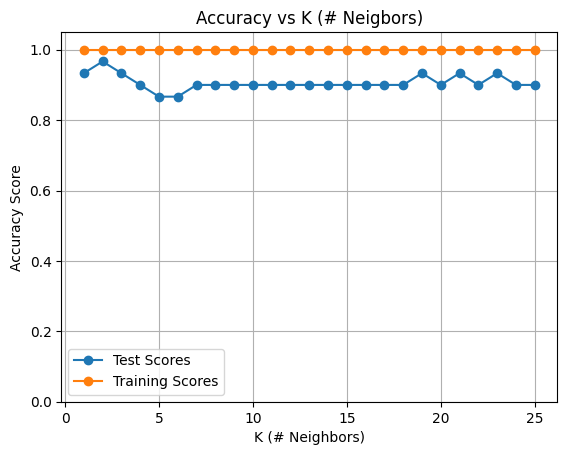

In [ ]:
# Train/Predict lymph with your own distance metric

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


# the metric, as given in the assignment details
def mixed_metric(x, y, NOMINAL_MASK):
    d = 0.0
    for i, is_nominal in enumerate(NOMINAL_MASK):
        if is_nominal:
            d += 0 if x[i] == y[i] else 1
        else:
            d += (x[i] - y[i]) ** 2
    return d**0.5


def main():
    # good golly this was a pain in the butt
    URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/lymphography/lymphography.data"

    COLUMNS = [
        "class",
        "lymphatics",
        "block of affere",
        "bl. of lymph. c",
        "bl. of lymph. s",
        "by pass",
        "extravasates",
        "regeneration of",
        "early uptake in",
        "lym.nodes dimin",
        "lym.nodes enlar",
        "changes in lym",
        "defect in node",
        "changes in node",
        "changes in stru",
        "special forms",
        "dislocation of",
        "exclusion of no",
        "no. of nodes in",
    ]

    df = pd.read_csv(URL, header=None, names=COLUMNS)
    X = df.drop(columns=["class"])
    y = df["class"]

    # print(X.shape)
    # print(X.isna().sum())
    # print(X.head())

    CONTINUOUS = {"lym.nodes dimin", "lym.nodes enlar", "no. of nodes in"}
    NOMINAL_MASK = [name not in CONTINUOUS for name in X.columns]

    # use label encoding on X
    for i, is_nominal in enumerate(NOMINAL_MASK):
        if not is_nominal:
            continue

        column = X.iloc[:, i]
        encoder = LabelEncoder()
        encoded_column = encoder.fit_transform(column)
        X.iloc[:, i] = np.asarray(encoded_column)

    # transform into numpy for ease of use with metrics
    X_arr = X.to_numpy(dtype=float)
    y_arr = y.to_numpy()

    # define the testing set
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, y_arr, test_size=0.2, random_state=43
    )
    # do some normalization
    norm = MinMaxScaler()

    # get the indexes of the continuous variables
    cont_idx = [i for i, is_nominal in enumerate(NOMINAL_MASK) if not is_nominal]

    # apply the normalization to the numerical values
    X_train[:, cont_idx] = norm.fit_transform(X_train[:, cont_idx])
    X_test[:, cont_idx] = norm.transform(X_test[:, cont_idx])

    iter_num = 25
    train_scores, test_scores = [], []

    # let's try some variable Ks
    for i in range(iter_num):
        K = i + 1
        clf = KNeighborsClassifier(
            n_neighbors=K,
            weights="distance",
            metric=mixed_metric,
            metric_params={"NOMINAL_MASK": NOMINAL_MASK},
        )

        clf.fit(X_train, y_train)
        train_score = clf.score(X_train, y_train)
        test_score = clf.score(X_test, y_test)
        print("Results")
        print("\tK:\t\t", K)
        print("\tTraining Set Score\t", train_score)
        print("\tTesting Set Score\t", test_score, "\n\n")
        train_scores.append(train_score)
        test_scores.append(test_score)

    pd.DataFrame(
        {"Test Scores": test_scores, "Training Scores": train_scores},
        index=range(1, iter_num + 1),
    ).plot(
        marker="o",
        xlabel="K (# Neighbors)",
        ylabel="Accuracy Score",
        ylim=(0, 1.05),
        title="Accuracy vs K (# Neigbors)",
        grid=True,
    )

    plt.show()


if __name__ == "__main__":
    main()





#### Discussion
Explain your distance metric and discuss your results

So, rather than pick just one K, I decided to look at which K would be the most accurate for the single testing set.

The result, based on random state 43?
k=2 with 0.9666666666666667 accuracy.

That could be a semi-random result, so I ran it with several different random states for the testing set. So, let's try out a few other random states to find out the optimal K across multiple testing sets.

|State|K=|~Acc. %|Table Desc|
|---|---|---|---|
|0|5|84|Begins low, reaches max at 5, wobbles up and down|
|1|5|88|Begins low, maxes out at 5-8, then goes down|
|2|15|90|Begins low, rises gradually, maxes at 15, bounces around, and then goes down|
|3|3|75|Maxes at three, bounces around, gradually decreases|
|4|4|90|Maxes at 4-6, then bounces downwards|
|5|3 or 11| maxes at 3, bounces around, hits the same value @ 11, then bounces around|

Given these: the ideal K is probably around 5.





## 5. (Optional 15% extra credit) Code up your own KNN Learner
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below
- Use Euclidean distance to decide closest neighbors
- Implement both the classification and regression versions
- Include optional distance weighting for both algorithms
- Run your algorithm on the magic telescope and housing data sets above and discuss and compare your results

*Discussion*

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class KNNClassifier(BaseEstimator,ClassifierMixin):
    def __init__(self, columntype=[], weight_type='inverse_distance'): ## add parameters here
        """
        Args:
            columntype for each column tells you if continues[real] or if nominal[categoritcal].
            weight_type: inverse_distance voting or if non distance weighting. Options = ["no_weight","inverse_distance"]
        """
        self.columntype = columntype #Note This won't be needed until part 5
        self.weight_type = weight_type

    def fit(self, data, labels):
        """ Fit the data; run the algorithm (for this lab really just saves the data :D)
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        return self

    def predict(self, data):
        """ Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        pass

    #Returns the Mean score given input data and labels
    def score(self, X, y):
        """ Return accuracy of model on a given dataset. Must implement own score function.
        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets
        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """
        return 0